In [1]:
import os
import json
import glob
import matplotlib.pyplot as plt

import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qaoa_training_pipeline.utils.graph_utils import load_graph, solve_max_cut, graph_to_operator
from qopt_best_practices.cost_function.cost_utils import counts_to_maxcut_cost
from qaoa_parameter_setting.utils.analysis import mean_obj, standard_error_mean

C:\Users\maosh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\cotengra\hyperoptimizers\hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
C:\Users\maosh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\cotengra\hyperoptimizers\hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
C:\Users\maosh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\cotengra\hyperoptimizers\hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
depth   = 2        # depth value
num_files   = 10   # number of files 


# instance = "_30nodes_random3regular.json"
# short_name = "N30R3R"
# folder = "random_regular"
# instance = "_7_3_heavyhex_144nodes_weighted.json"
# short_name = "N144HH73"
# folder = "heavy_hex"
# instance = "_40nodes_erdosrenyi20percent.json"
# short_name = "N40ER20"
# folder = "erdos_renyi"
instance = "_100nodes_2swap_layers.json"
short_name = "N100L2S2"
folder = "line_to_full"

all_summaries = []
matches = []
for n in range(num_files):
    prefix = f"data/hardware/{folder}/00{n}{short_name}_{depth}"
    found = glob.glob(prefix + "*.json")
    matches.extend(found)

In [3]:
def load_json(partial_name, directory="."):

    pattern = os.path.join(directory, f"*{partial_name}*.json")
    matches = glob.glob(pattern)

    if not matches:
        raise FileNotFoundError(f"No JSON files found matching: {partial_name}")

    with open(matches[0], "r") as f:
        data = json.load(f)
    return data

In [5]:
result_repo=f"../QAOA-Parameter-Setting/data/training/{folder}"
max_cuts=[]
min_cuts=[]
ar_diffs=[]
for n in range(num_files):
    data = load_json(f"00{n}{short_name}_MC", directory=result_repo)
    cost_op = SparsePauliOp.from_list(data["cost_operator"])
    max_cut, min_cut, ar = solve_max_cut(cost_op,  data["1"]["energy"])
    ar_diff= ar*(max_cut-min_cut)- data["1"]["energy"]
    max_cuts.append(max_cut)
    min_cuts.append(min_cut)
    ar_diffs.append(ar_diff)
    print(n)

0
1
2
3
4
5
6
7
8
9


In [6]:
all_methods = []
file_data   = []

for fname in matches:
    try:
        with open(fname, "r") as fin:
            res_summary = json.load(fin)

        methods = set()
        energies = {}
        basename = os.path.basename(fname)   # '001N40R3R_3_d4kbkgqv0j9c73e46o50.json'
        prefix_digits = ''.join([c for c in basename if c.isdigit()][:3])  
        n = int(prefix_digits)
        graph = load_graph(f"instances/{folder}/00{n}{instance}")
        mc_costs = [counts_to_maxcut_cost(graph, res["counts"]) for res in res_summary]
        means = [100*(mean_obj(mc_cost)-min_cuts[n])/(max_cuts[n]-min_cuts[n]) for mc_cost in mc_costs]
        sems = np.array([100*(standard_error_mean(mc_cost, sum(res_summary[idx]["counts"].values())))/(max_cuts[n]-min_cuts[n]) for idx, mc_cost in enumerate(mc_costs)])
        for idx, mc_cost in enumerate(mc_costs):
            try:
                label =res_summary[idx]["metadata"]["circuit_metadata"]["method"]
                val   = res_summary[idx]["metadata"]["circuit_metadata"]["eval_energy"]  
                methods.add(label)
                energies.setdefault(label, []).append([val,means[idx],sems[idx]])
            except (KeyError, TypeError):
                continue

        all_methods.append(methods)
        file_data.append(energies)

    except FileNotFoundError:
        print(f"Missing file: {fname}")
    print(n)

# Find shared labels
shared_labels = set.intersection(*all_methods)
print("Shared labels:", shared_labels)

# Collect energies per label 
energy_dict = {label: [] for label in shared_labels}
for energies in file_data:
    for label in shared_labels:
        if label in energies:
            energy_dict[label].append(energies[label])

0
1
2
3
4
5
6
7
8
9
Shared labels: {'TQA_PP_opt_2', 'FA_PP_opt_2', 'FA_MPS_opt_2', 'F_MPS_10', 'I_PP_10', 'F_PP_10', 'TQA_MPS_opt_2', 'I_MPS_10'}


In [7]:
prefix_map = {
    "F": ["FOURIER", 0],
    "FA": ["fixed angles", 1],
    "I": ["INTERP", 2],
    "TQA": ["TQA", 3]
}

evaluator_map = {
    "MPS": 0,
    "PP": 1,
}
def expand_abbreviation(abbr, prefix_map, depth):
    parts = abbr.split('_')
    if parts[2]=="opt":
        expanded= f"reoptmized {prefix_map[parts[0]][0]} with {parts[1]}({depth})"
    else:
        expanded= f"{prefix_map[parts[0]][0]} with {parts[1]}({depth})"
    return expanded



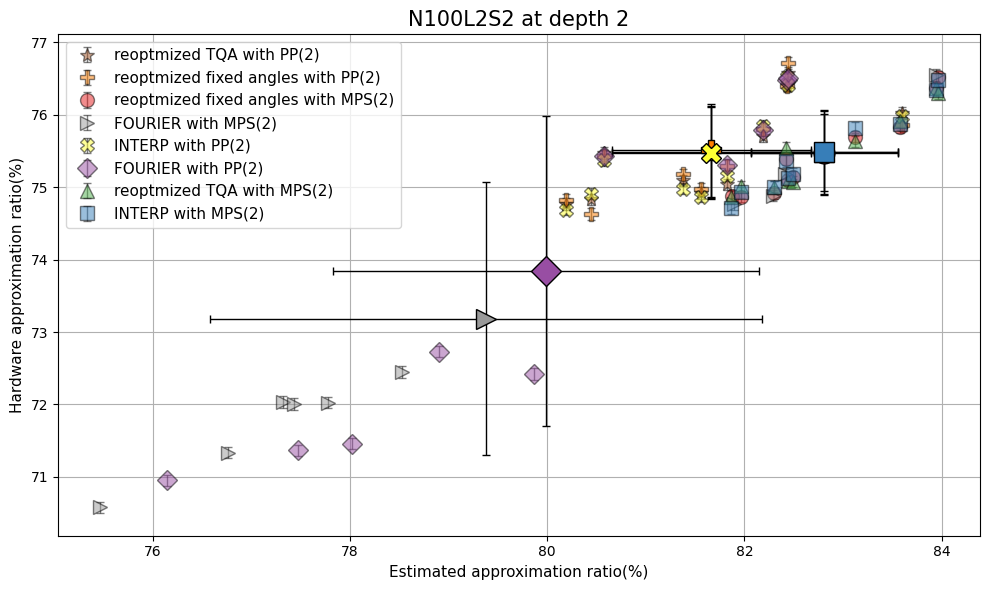

In [8]:
opts = { "mec": "k", "ecolor": "k", "capsize": 3, "elinewidth": 1}

fig=plt.figure(figsize=(10, 6))
colors = plt.cm.Set1.colors
marker_styles = ["o", "s", "^", "D", "P", "X", "*", "v", "<", ">"]

for i, label in enumerate(shared_labels):
    parts = label.split('_')
    ind=evaluator_map[parts[1]]*4+prefix_map[parts[0]][1]-1
    arr = np.array(energy_dict[label]) 
    arr0 =(arr[:, 0, 0]+np.array(ar_diffs).T)/(np.array(max_cuts).T-np.array(min_cuts).T)
    plt.errorbar(100*arr0.flatten(), arr[:, 0, 1], yerr=arr[:, 0, 2], fmt=marker_styles[ind],
                 label=expand_abbreviation(label, prefix_map, depth), linestyle="none",
                 color=colors[ind % len(colors)],alpha=0.5, ms=10,
                 **opts)
    plt.errorbar(np.average(100*arr0.flatten()), np.average(arr[:, 0, 1]), xerr=np.std(100*arr0.flatten()), yerr=np.std(arr[:, 0, 1]), fmt=marker_styles[ind],
                  linestyle="none",
                 color=colors[ind % len(colors)], ms=15, **opts)

plt.xlabel("Estimated approximation ratio(%)",fontsize=11)
plt.ylabel("Hardware approximation ratio(%)",fontsize=11)
plt.title(f"{short_name} at depth {depth}",fontsize=15)
plt.legend(fontsize=11)  
plt.grid(True)
plt.tight_layout()
plt.show()
fig.savefig(f"{short_name}_{depth}_HW_r.pdf")

In [11]:
import pandas as pd
from scipy import stats
import scikit_posthocs as sp

data_est={}
data_hw={}
for i, label in enumerate(shared_labels):
    arr = np.array(energy_dict[label])
    arr0 =(arr[:, 0, 0]+np.array(ar_diffs).T)/(np.array(max_cuts).T-np.array(min_cuts).T)
    data_est[label]= 100*arr0.flatten()
    data_hw[label]= arr[:, 0, 1]
    
def add_sig_stars(pval):
    if pval < 0.001:
        return '***'
    elif pval < 0.01:
        return '**'
    elif pval < 0.05:
        return '*'
    else:
        return ''


def dataset_test(data, label="Dataset"):
    
    df = pd.DataFrame({
        'score': np.concatenate(list(data.values())),
        'Method': sum([[m]*len(v) for m,v in data.items()], [])
    })

    # Kruskal–Wallis test
    groups = [df.loc[df['Method']==m, 'score'] for m in data.keys()]
    H, p = stats.kruskal(*groups)

    group_medians = df.groupby('Method')['score'].median()

    # Conover–Iman posthoc with Holm correction
    conover_results = sp.posthoc_conover(df, val_col='score', group_col='Method', p_adjust='holm')
    posthoc_star = conover_results.map(lambda p: f"{p:.3g} {add_sig_stars(p)}")

    posthoc_star['Median'] = group_medians
    order = group_medians.sort_values(ascending=False).index
    results = posthoc_star.loc[order, order].assign(Median=group_medians[order])
    results.index.name = None

    print(f"\nKruskal–Wallis omnibus test on {label}: H={H:.3f}, p={p:.3e}")
    print(f"\nConover–Iman test (Holm correction) on {label}:\n", results)

    return H, p, results

# Run for both datasets
H_est, p_est, est_results = dataset_test(data_est, label="estimated ratios")
H_hw, p_hw, hw_results   = dataset_test(data_hw, label="hardware ratios")






Kruskal–Wallis omnibus test on estimated ratios: H=29.011, p=1.440e-04

Conover–Iman test (Holm correction) on estimated ratios:
 Method        FA_MPS_opt_2    I_MPS_10 TQA_MPS_opt_2 FA_PP_opt_2 I_PP_10  \
FA_MPS_opt_2            1           1             1        0.18   0.161    
I_MPS_10                1           1             1       0.204   0.185    
TQA_MPS_opt_2           1           1             1        0.23   0.212    
FA_PP_opt_2          0.18       0.204          0.23           1       1    
I_PP_10             0.161       0.185         0.212           1       1    
TQA_PP_opt_2         0.18       0.204          0.23           1       1    
F_PP_10         0.00369 **  0.00489 **    0.00665 **          1       1    
F_MPS_10        0.00277 **   0.0037 **    0.00508 **          1       1    

Method        TQA_PP_opt_2     F_PP_10    F_MPS_10     Median  
FA_MPS_opt_2         0.18   0.00369 **  0.00277 **  82.471013  
I_MPS_10            0.204   0.00489 **   0.0037 **  82.4

In [10]:
import re

def df_to_latex_with_hlines(df):
    latex = df.to_latex(
        escape=True,
        float_format="%.3g",
        index=True,
        na_rep="--",
        column_format="|l|" + "c|"*(df.shape[1]),
 
    )
    latex = (latex
             .replace("\\toprule", "")
             .replace("\\midrule", "")
             .replace("\\bottomrule", ""))
    latex = latex.replace("\\\\\n", "\\\\ \\hline\n")
    latex = re.sub(r"(\\begin\{tabular\}\{.*?\}\n)", r"\1\\hline\n", latex)
    return latex

# Export both tables
est_latex = df_to_latex_with_hlines(est_results)
hw_latex = df_to_latex_with_hlines(hw_results)

latex_code = (
    "\\begin{table}[ht]\n"
    "\\centering\n"
    "\\resizebox{\\textwidth}{!}{%\n" +
    est_latex +
    "}\n"
    "\\vspace{0.5em}\n\n"
    "\\resizebox{\\textwidth}{!}{%\n" +
    hw_latex +
    "}\n"+
    "\\caption{Conover–Iman's post-hoc test with Holm correction on estimated(top) and hardware(bottom) ratios generated from}\n"+
    "\\end{table}"
)

print(latex_code)


\begin{table}[ht]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|}
\hline

Method & FA\_MPS\_opt\_2 & I\_MPS\_10 & TQA\_MPS\_opt\_2 & FA\_PP\_opt\_2 & I\_PP\_10 & TQA\_PP\_opt\_2 & F\_PP\_10 & F\_MPS\_10 & Median \\ \hline

FA\_MPS\_opt\_2 & 1  & 1  & 1  & 0.18  & 0.161  & 0.18  & 0.00369 ** & 0.00277 ** & 82.5 \\ \hline
I\_MPS\_10 & 1  & 1  & 1  & 0.204  & 0.185  & 0.204  & 0.00489 ** & 0.0037 ** & 82.5 \\ \hline
TQA\_MPS\_opt\_2 & 1  & 1  & 1  & 0.23  & 0.212  & 0.23  & 0.00665 ** & 0.00508 ** & 82.5 \\ \hline
FA\_PP\_opt\_2 & 0.18  & 0.204  & 0.23  & 1  & 1  & 1  & 1  & 1  & 81.7 \\ \hline
I\_PP\_10 & 0.161  & 0.185  & 0.212  & 1  & 1  & 1  & 1  & 1  & 81.7 \\ \hline
TQA\_PP\_opt\_2 & 0.18  & 0.204  & 0.23  & 1  & 1  & 1  & 1  & 1  & 81.7 \\ \hline
F\_PP\_10 & 0.00369 ** & 0.00489 ** & 0.00665 ** & 1  & 1  & 1  & 1  & 1  & 80.2 \\ \hline
F\_MPS\_10 & 0.00277 ** & 0.0037 ** & 0.00508 ** & 1  & 1  & 1  & 1  & 1  & 78.2 \\ \hline

\end{tabular}
}
\vspace{0.